# Cutout extraction — set params, run, inspect quality

A slimmed sibling of `cutout_analysis.ipynb`: the **x/y/time cutout is hardcoded**
(section 1), you **tune `min_corr` / `min_pnr`** against the cutout's own CORR·PNR
seed map with sliders (section 3), then **run the extraction** (section 4) and look
at **extraction-quality images** (section 5).

The slider preview uses `detect_seeds` (the corr·pnr local-maxima map the greedy
init seeds from) — it is the fast, standard indicator of how the thresholds change
detection. It is an *upper bound* on the neurons actually kept after the greedy
accept/reject + merge. There is an optional button to run the true greedy init at
the current thresholds.


## 1. Config + cutout (EDIT ME)

In [13]:
%matplotlib inline
import sys, time
from dataclasses import replace
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/home/fs539/code/simpler_cnmfe')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from cnmfe.io import open_zarr
from cnmfe.pipeline import CNMFe, CNMFeParams

# --- movie / output ----------------------------------------------------------
MOVIE_ZARR = Path('/media/server/archive/projects/2023_intercontext/ToneComparison/data/1_preprocessed/20260520_m0010798_wt_1051/miniscope_video/mc.zarr')
OUTPUT_DIR = Path('/home/fs539/code/simpler_cnmfe/tmp/cutout_extract')
DO_MC      = False     # True if MOVIE_ZARR is raw; False if already corrected

# --- cutout: x / y / time mask (kept hardcoded, like the patch) --------------
CROP_Y  = (60, 240)      # rows    -> spatial_crop y0:y1
CROP_X  = (60, 240)      # cols    -> spatial_crop x0:x1
T_RANGE = (1000, 5000)   # frames  -> temporal_crop t0:t1
MASK_NPY = None          # optional bool (H, W) .npy path -> spatial_mask_path

# --- extraction params (NATIVE units; cutout fields added in section 4) ------
SIGMA = 3.0
PARAMS = CNMFeParams(
    sigma=SIGMA, min_corr=0.8, min_pnr=8.0,
    n_iter_main=2, n_iter_temporal=2,          # 2 BCD iters -> sharper demixing / cleaner C vs C+YrA at high K (drop to 1 for speed)
    # --- drift + dense-field defaults (tuned on a real long recording; see cutout_analysis) ---
    global_bg_rank=1,                          # absorb slow drift/bleaching as a rank-1 temporal background
    spatial_max_thr=0.25,                      # tighter footprints (halo cut at 25% of peak) -> less cross-talk
    spatial_circular_max_dist_factor=1.2,      # tighter radial clip
    merge_thr_corr=0.90,                       # gentle merge: don't fuse distinct co-active neighbours
    merge_centre_dist_factor=1.0,              # centre-distance fallback ~1 sigma (not 2)
    # init_stride stays auto (=1 for this short window); set 1-2 explicitly for a very long T_RANGE
    max_shift=(20, 20), mc_gSig_filt=7, mc_n_iter=1,
    n_jobs=-1, decay_time_ms=180, g_prior_weight=0.7, spatial_max_iter=20000,
)

# explorer speed: stride time when sampling the cutout for CORR/PNR
EXPLORE_STRIDE = 2

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
y0, y1 = CROP_Y; x0, x1 = CROP_X; t0, t1 = T_RANGE
print('movie :', MOVIE_ZARR)
print('output:', OUTPUT_DIR, '| DO_MC =', DO_MC)
print(f'cutout: Y[{y0}:{y1}] X[{x0}:{x1}] T[{t0}:{t1}]  mask={MASK_NPY}')
assert MOVIE_ZARR.exists(), f'movie zarr not found: {MOVIE_ZARR}'


movie : /media/server/archive/projects/2023_intercontext/ToneComparison/data/1_preprocessed/20260520_m0010798_wt_1051/miniscope_video/mc.zarr
output: /home/fs539/code/simpler_cnmfe/tmp/cutout_extract | DO_MC = False
cutout: Y[60:240] X[60:240] T[1000:5000]  mask=None


## 2. Load cutout sample + reference images

movie: (37398, 300, 300)  dtype=float32  chunks=(1000, 300, 300)
cutout sample: (2000, 180, 180)  (180x180, every 2 frames)


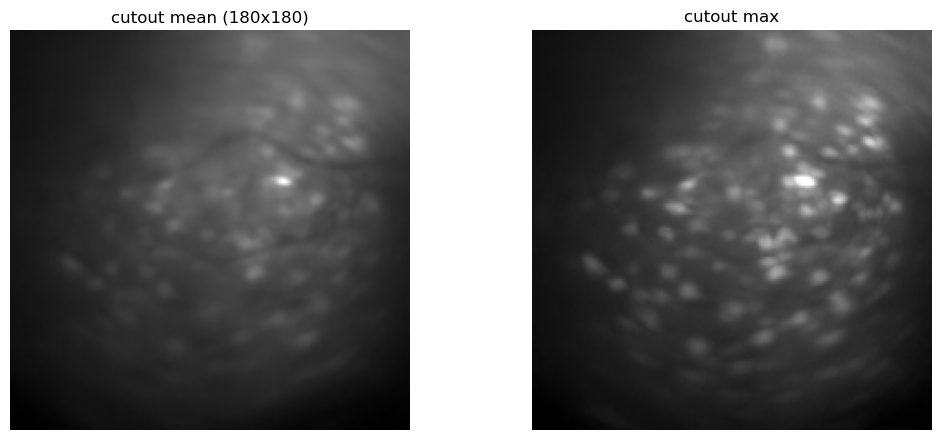

In [14]:
z = open_zarr(MOVIE_ZARR)
T, H, W = z.shape
print(f'movie: {z.shape}  dtype={z.dtype}  chunks={z.chunks}')
assert 0 <= y0 < y1 <= H and 0 <= x0 < x1 <= W and 0 <= t0 < t1 <= T, 'cutout out of bounds'

# Strided, cropped float32 sample of the cutout for the threshold explorer.
samp = np.asarray(z[t0:t1:EXPLORE_STRIDE, y0:y1, x0:x1], dtype=np.float32)
mean_img = samp.mean(0)
max_img  = samp.max(0)
hc, wc = mean_img.shape
print(f'cutout sample: {samp.shape}  ({hc}x{wc}, every {EXPLORE_STRIDE} frames)')

# Optional ROI mask, cropped to the cutout (for display only here).
mask_crop = None
if MASK_NPY is not None:
    m = np.load(MASK_NPY).astype(bool)
    assert m.shape == (H, W), f'mask {m.shape} != movie {(H, W)}'
    mask_crop = m[y0:y1, x0:x1]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].imshow(mean_img, cmap='gray'); ax[0].set_title(f'cutout mean ({hc}x{wc})'); ax[0].axis('off')
ax[1].imshow(max_img,  cmap='gray'); ax[1].set_title('cutout max');  ax[1].axis('off')
if mask_crop is not None:
    for a in ax: a.contour(mask_crop, [0.5], colors='cyan', linewidths=0.8)
plt.tight_layout(); plt.show()


## 3. Tune `min_corr` / `min_pnr`

CORR and PNR are computed **once** on the cutout sample at `SIGMA`. Move the sliders
to see the candidate seeds (`detect_seeds`) — these are the pixels the greedy init
seeds from, so the count tracks how the thresholds change detection. Read your chosen
values off the title and type them into section 4.

In [15]:
from cnmfe.preprocess import correlation_pnr
from cnmfe.initialization import detect_seeds

t_cn = time.time()
cn, pnr = correlation_pnr(samp, sigma=SIGMA, center_psf=True, n_jobs=-1)
score = cn * pnr
print(f'CORR/PNR computed in {time.time()-t_cn:.1f}s  (shape {cn.shape})')

def _pct(a, label):
    a = a[np.isfinite(a)]
    print(f'  {label:5s} p50/p90/p99/max = '
          + ' / '.join(f'{v:.2f}' for v in np.percentile(a, [50, 90, 99, 100])))
_pct(cn, 'corr'); _pct(pnr, 'pnr')


CORR/PNR computed in 4.1s  (shape (180, 180))
  corr  p50/p90/p99/max = 0.79 / 0.97 / 1.00 / 1.00
  pnr   p50/p90/p99/max = 10.05 / 26.25 / 44.58 / 64.26


Output()

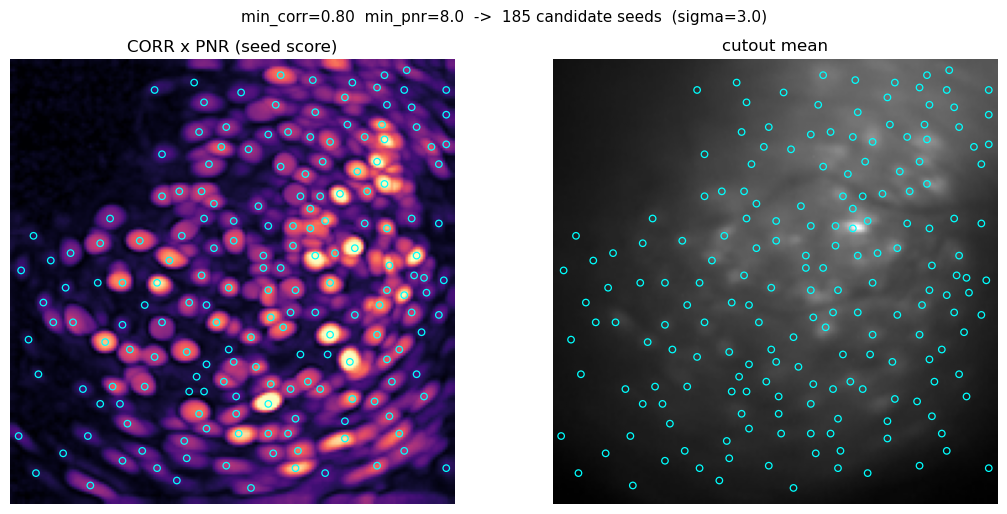

In [16]:
import ipywidgets as widgets
from IPython.display import display

VMAX_SC = float(np.nanpercentile(score, 99.5))

def _show_seeds(min_corr, min_pnr):
    seeds = detect_seeds(cn, pnr, min_corr=min_corr, min_pnr=min_pnr,
                         min_distance=max(1, int(SIGMA)))
    fig, ax = plt.subplots(1, 2, figsize=(11, 5.2))
    ax[0].imshow(score, cmap='magma', vmin=0, vmax=VMAX_SC)
    ax[0].set_title('CORR x PNR (seed score)')
    ax[1].imshow(mean_img, cmap='gray'); ax[1].set_title('cutout mean')
    if seeds.size:
        for a in ax:
            a.scatter(seeds[:, 1], seeds[:, 0], s=22, facecolors='none',
                      edgecolors='cyan', linewidths=0.9)
    for a in ax: a.axis('off')
    fig.suptitle(f'min_corr={min_corr:.2f}  min_pnr={min_pnr:.1f}  ->  '
                 f'{len(seeds)} candidate seeds  (sigma={SIGMA})', fontsize=11)
    plt.tight_layout(); plt.show()

mc_sl = widgets.FloatSlider(value=float(PARAMS.min_corr), min=0.50, max=0.95, step=0.01,
                            description='min_corr', continuous_update=False,
                            readout_format='.2f', layout=widgets.Layout(width='95%'))
mp_sl = widgets.FloatSlider(value=float(PARAMS.min_pnr), min=1.0, max=30.0, step=0.5,
                            description='min_pnr', continuous_update=False,
                            readout_format='.1f', layout=widgets.Layout(width='95%'))
out = widgets.interactive_output(_show_seeds, {'min_corr': mc_sl, 'min_pnr': mp_sl})
display(widgets.VBox([mc_sl, mp_sl]), out)
# Render once so the cell shows a figure even without interaction (headless run).
_show_seeds(float(PARAMS.min_corr), float(PARAMS.min_pnr))


In [17]:
# OPTIONAL: run the TRUE greedy init at the current slider thresholds (slow, ~10-30s).
# Gives the actual K (after accept/reject) rather than the seed upper bound.
from cnmfe.initialization import greedy_corr_pnr

run_btn = widgets.Button(description='Run greedy init at current thresholds',
                         layout=widgets.Layout(width='auto'))
run_out = widgets.Output()

def _run_greedy(_):
    with run_out:
        run_out.clear_output()
        t = time.time()
        A, C, C_raw, centers = greedy_corr_pnr(
            samp, sigma=SIGMA, min_corr=mc_sl.value, min_pnr=mp_sl.value,
            min_pixel=PARAMS.min_pixel, n_jobs=-1)
        print(f'min_corr={mc_sl.value:.2f} min_pnr={mp_sl.value:.1f} '
              f'-> {A.shape[1]} neurons (greedy, {time.time()-t:.1f}s)')

run_btn.on_click(_run_greedy)
display(run_btn, run_out)


Button(description='Run greedy init at current thresholds', layout=Layout(width='auto'), style=ButtonStyle())

Output()

## 4. Set final thresholds + run extraction

37398

In [28]:
# Copy the values you chose in section 3.
MIN_CORR = float(PARAMS.min_corr)
MIN_PNR  = float(PARAMS.min_pnr)

MIN_CORR = 0.8
MIN_PNR = 8
params = replace(
    PARAMS,
    sigma=SIGMA, min_corr=MIN_CORR, min_pnr=MIN_PNR,
    temporal_crop=(0, np.shape(z)[0]),
    spatial_crop=(y0, y1, x0, x1),
    spatial_mask_path=(str(MASK_NPY) if MASK_NPY is not None else None),
)

t_start = time.time()
model = CNMFe(params).fit(z, do_motion_correction=DO_MC)
Kc = model.A.shape[1]
print(f'\nextracted {Kc} components in {time.time()-t_start:.1f}s')
print(f'cutout dims = {model.dims}   T = {model.C.shape[1]}')
print(f'min_corr={MIN_CORR}  min_pnr={MIN_PNR}  sigma={SIGMA}')


Cutout: T[0:37398] H[60:240] W[60:240] -> (37398, 180, 180)
Extraction config: n_jobs=-1 device=cpu T=37398 H=180 W=180 streaming=no (movie materialised in RAM)
Estimating noise...
Running greedy CORR-PNR initialization (init_stride=7, T_init=5343; corrpnr_stride=2, T_corrpnr=2671)...
  Found 362 initial components.
Fitting ring-model background (radius=10.5px, tsub=5)...
Fitting rank-1 global background b_f · f(t) (initial)...
Refinement iteration 1/2...
  Pre-merging duplicate seeds...
  291 components (53 pre-merged).
  Updating spatial footprints...
  update_spatial: 2/32400 pixels hit max_iter=20000 before converging (tol=0.0001). Increase CNMFeParams.spatial_max_iter or loosen spatial_tol to tighten.
  Updating temporal traces...
  Merging correlated components...
  274 components (11 merged).
Refinement iteration 2/2...
  Updating spatial footprints...
  Updating temporal traces...
  Merging correlated components...
  269 components (3 merged).
Final temporal update...
Auto-eval

## 5. Extraction quality

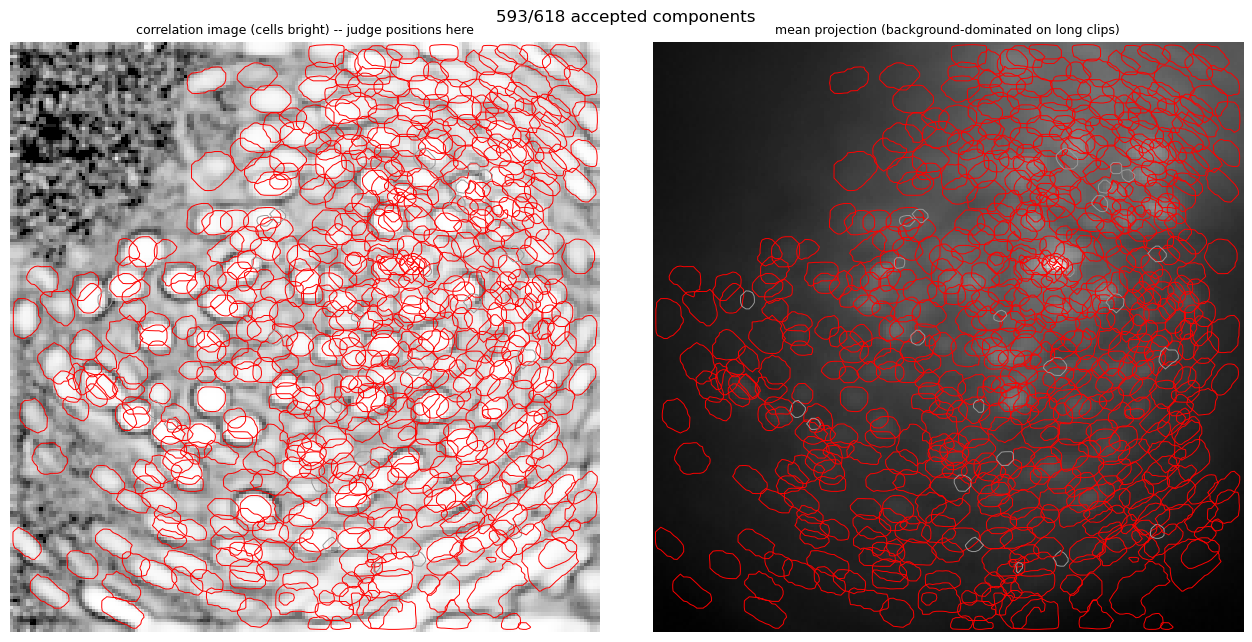

In [20]:
# 5a. Footprints over an ACTIVITY (correlation) image AND the mean projection.
# Judge positions on the correlation panel: neurons are bright there, whereas on
# long recordings the mean projection is dominated by static background, so
# footprints can look "off" the mean's bright spots even when they're on cells.
hc, wc = model.dims
A_dense = np.asarray(model.A.todense()).reshape(hc, wc, Kc)
peaks = A_dense.reshape(-1, Kc).max(0)
acc = model.accepted_mask if model.accepted_mask is not None else np.ones(Kc, bool)

# reuse the correlation image from section 3 if present, else compute it
if 'cn' not in globals():
    from cnmfe.preprocess import correlation_pnr
    cn, _pnr = correlation_pnr(samp, sigma=SIGMA, center_psf=True, n_jobs=-1)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
for ax, img, ttl in [(axes[0], cn,       'correlation image (cells bright) -- judge positions here'),
                     (axes[1], mean_img, 'mean projection (background-dominated on long clips)')]:
    ax.imshow(img, cmap='gray')
    for k in range(Kc):
        fp = A_dense[..., k]
        if fp.max() <= 0:
            continue
        ax.contour(fp, [fp.max() * 0.3], colors='red' if acc[k] else '0.6', linewidths=0.7)
    ax.set_title(ttl, fontsize=9); ax.axis('off')
fig.suptitle(f'{int(acc.sum())}/{Kc} accepted components')
plt.tight_layout(); plt.show()

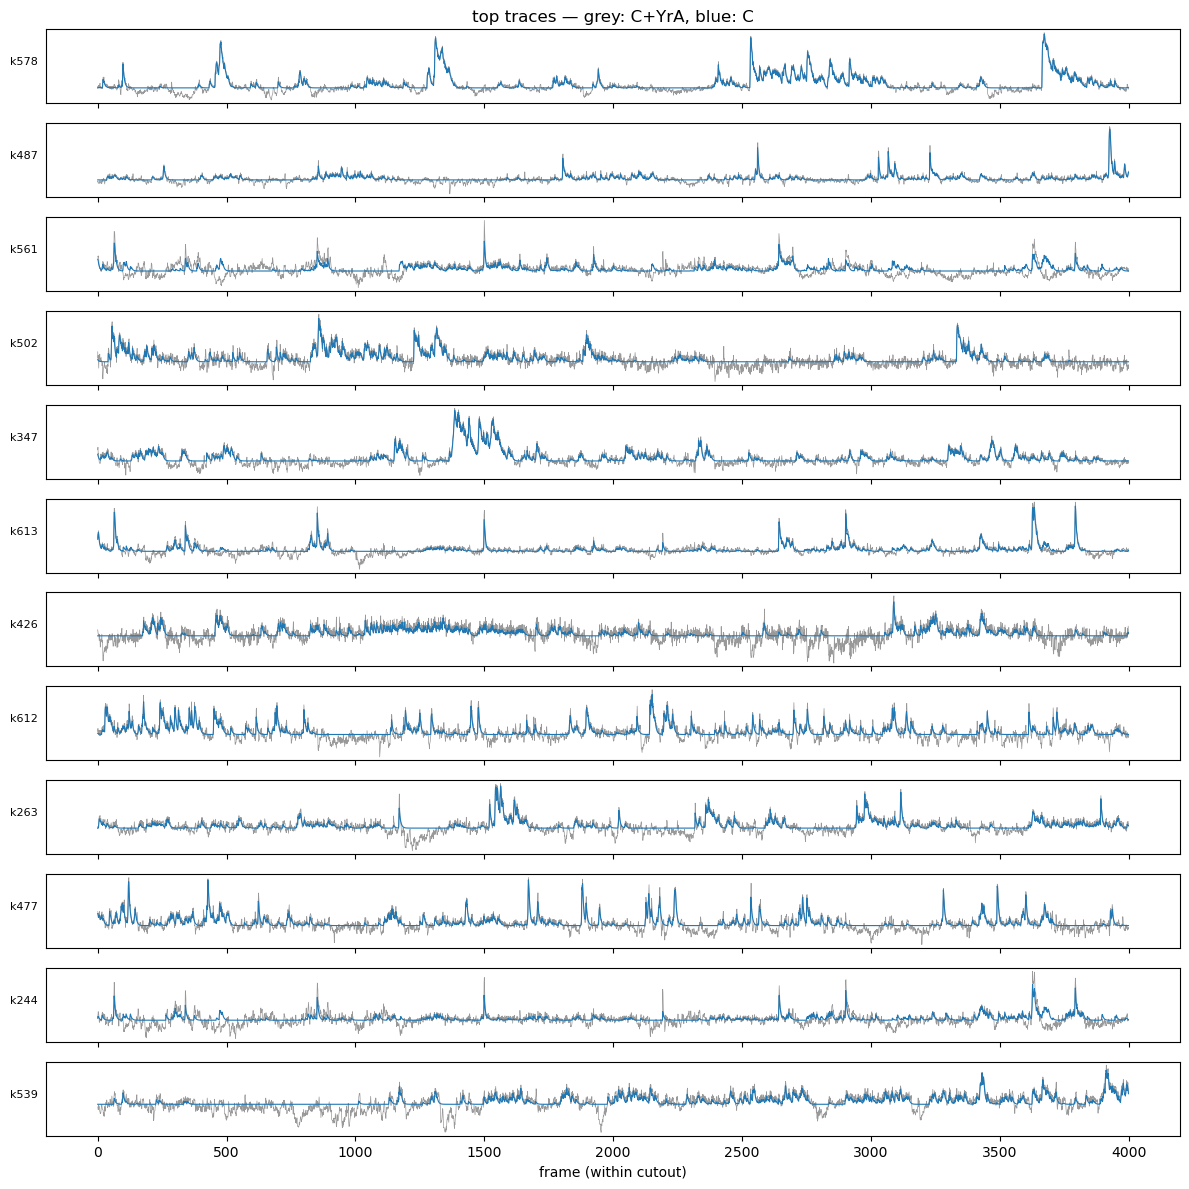

In [21]:
# 5b. Top-N traces: grey = C + YrA (noisy projected), blue = C (deconvolved).
N_TRACE = 12
pool = np.where(acc)[0]; pool = pool if pool.size else np.arange(Kc)
order = pool[np.argsort(-model.C[pool].max(1))][:min(N_TRACE, pool.size)]
n = len(order)
fig, axes = plt.subplots(n, 1, figsize=(12, 1.0 * n), sharex=True)
axes = np.atleast_1d(axes)
for axi, k in zip(axes, order):
    axi.plot(model.C[k] + model.YrA[k], color='0.6', lw=0.5)
    axi.plot(model.C[k], color='C0', lw=0.8)
    axi.set_ylabel(f'k{k}', rotation=0, labelpad=16, fontsize=8); axi.set_yticks([])
axes[0].set_title('top traces — grey: C+YrA, blue: C')
axes[-1].set_xlabel('frame (within cutout)')
plt.tight_layout(); plt.show()


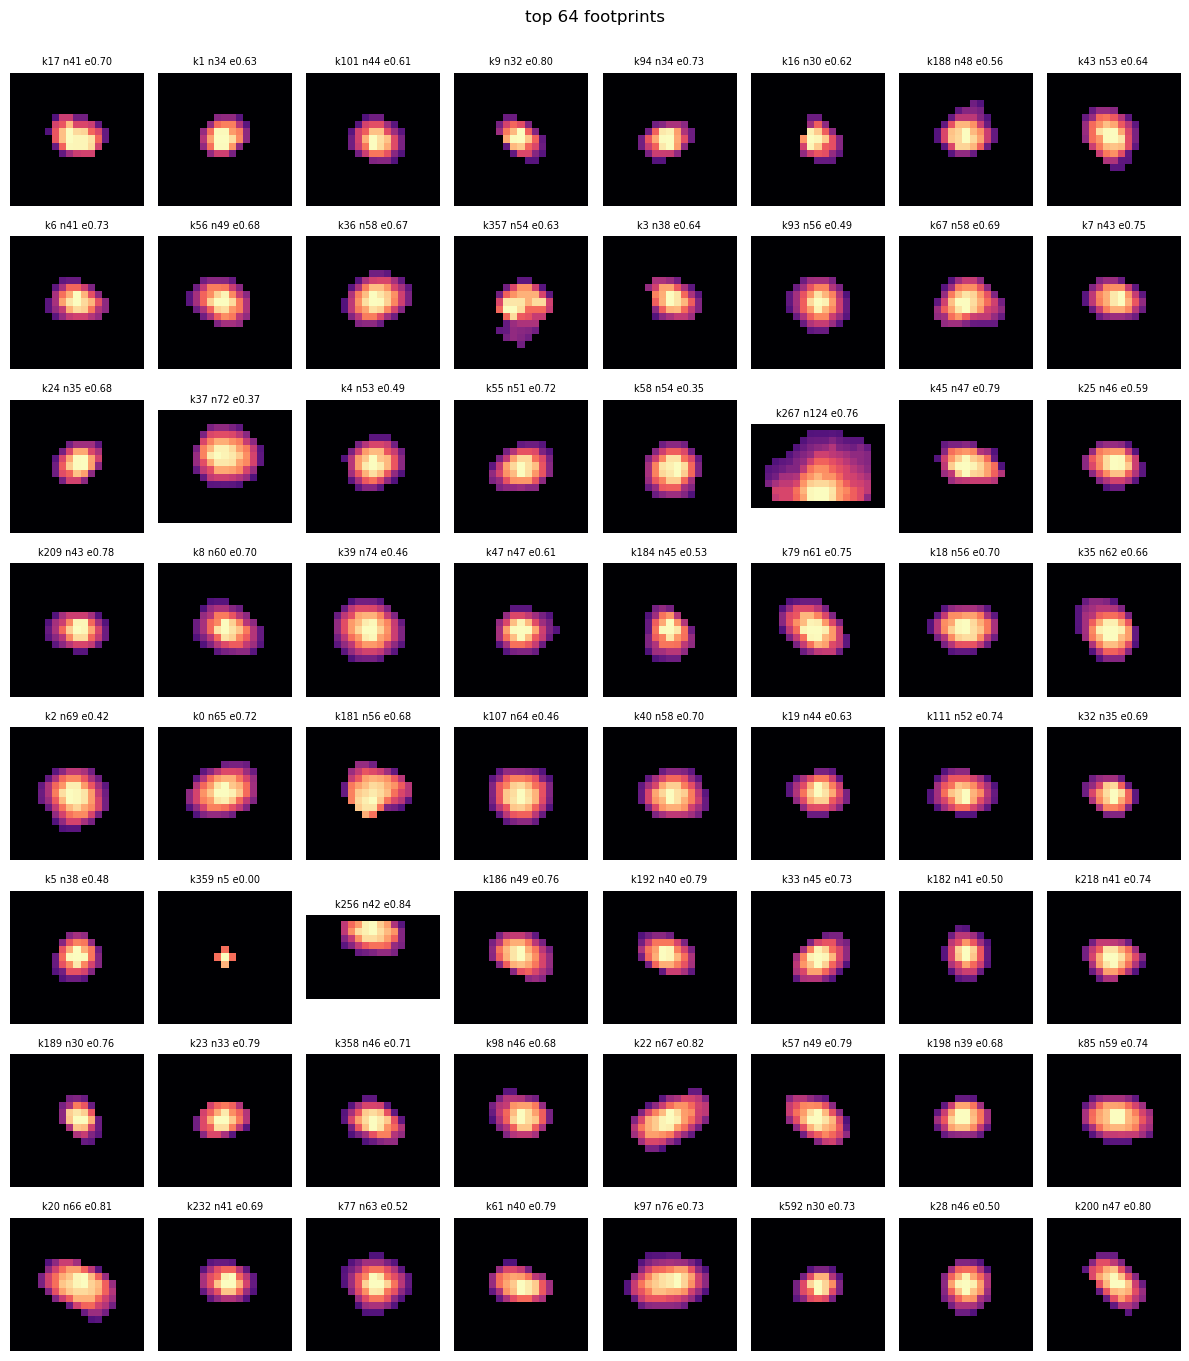

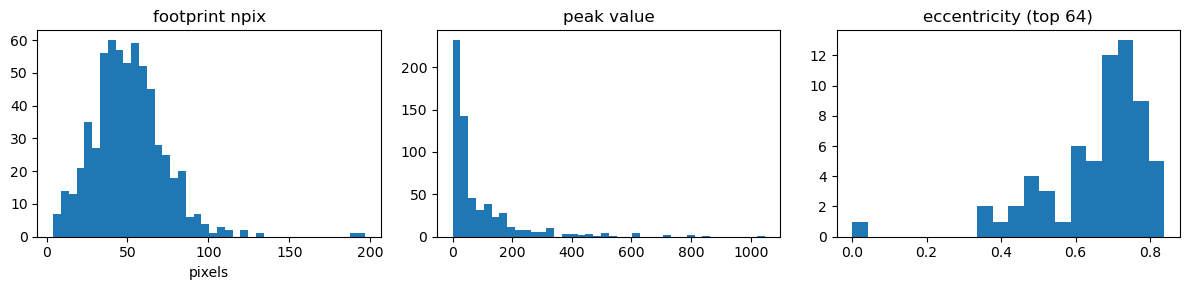

median footprint area 49 px (expected ~113 px for 2sigma); K=618


In [22]:
# 5c. Footprint gallery (top-N, centred on footprint_center) + shape histograms.
from cnmfe._utils import footprint_center

N_SHOW = 64
CROP_R = max(8, int(3 * SIGMA))
order = np.argsort(-peaks)[:min(N_SHOW, Kc)]
stats = []
for k in order:
    fp = A_dense[..., k]; nz = fp > 0; npix = int(nz.sum())
    if npix == 0:
        continue
    cy, cx = footprint_center(fp)
    ys, xs = np.where(nz)
    if ys.size >= 2:
        eig = np.linalg.eigvalsh(np.cov(np.vstack([ys, xs])))
        ecc = float(np.sqrt(max(0.0, 1 - eig.min() / max(eig.max(), 1e-9))))
    else:
        ecc = 0.0
    stats.append((k, npix, float(fp.max()), ecc, (cy, cx)))

ncols = 8; nrows = int(np.ceil(len(stats) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(1.5 * ncols, 1.7 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, (k, npix, pk, ecc, (cy, cx)) in zip(axes, stats):
    yy0 = max(0, cy - CROP_R); yy1 = min(hc, cy + CROP_R + 1)
    xx0 = max(0, cx - CROP_R); xx1 = min(wc, cx + CROP_R + 1)
    ax.imshow(A_dense[yy0:yy1, xx0:xx1, k], cmap='magma', vmin=0, vmax=max(pk, 1e-9))
    ax.set_title(f'k{k} n{npix} e{ecc:.2f}', fontsize=7); ax.axis('off')
for ax in axes[len(stats):]:
    ax.axis('off')
plt.suptitle(f'top {len(stats)} footprints', y=1.002); plt.tight_layout(); plt.show()

all_npix = np.array([(A_dense[..., k] > 0).sum() for k in range(Kc)])
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].hist(all_npix, bins=40); ax[0].set_title('footprint npix'); ax[0].set_xlabel('pixels')
ax[1].hist(peaks, bins=40);    ax[1].set_title('peak value')
ax[2].hist([s[3] for s in stats], bins=20); ax[2].set_title(f'eccentricity (top {len(stats)})')
plt.tight_layout(); plt.show()
expected = int(np.pi * (2 * SIGMA) ** 2)
print(f'median footprint area {int(np.median(all_npix))} px (expected ~{expected} px for 2sigma); K={Kc}')


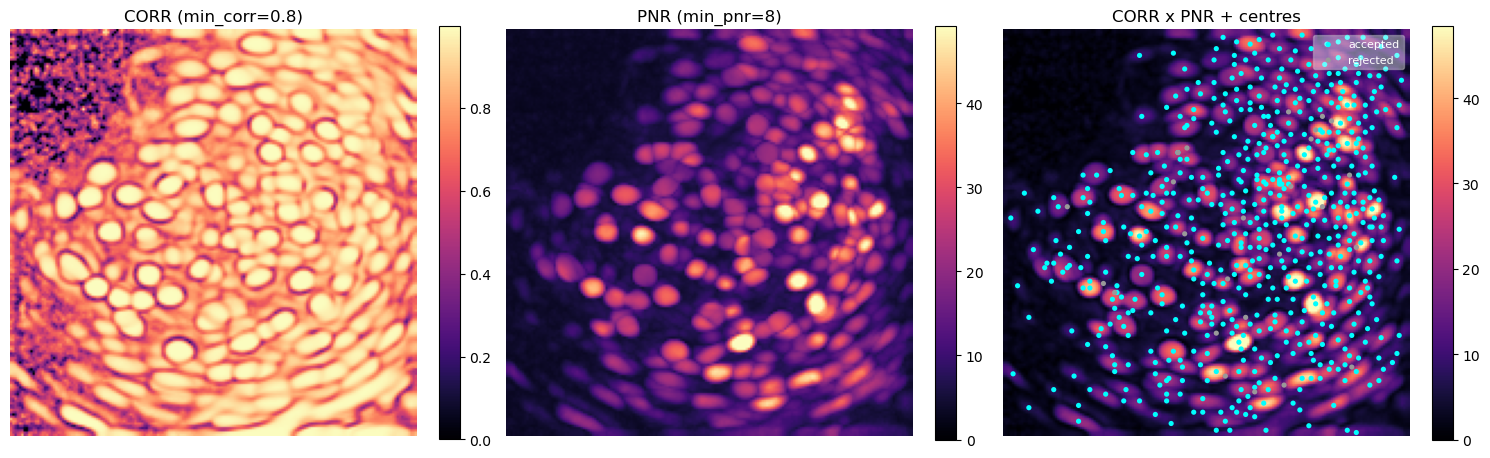

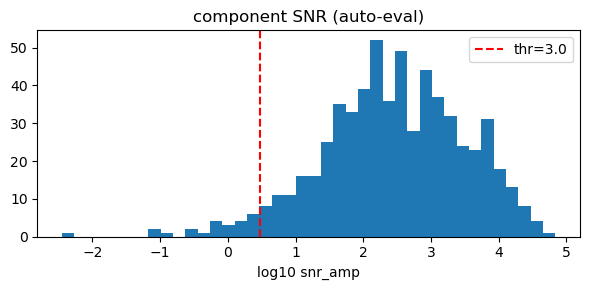

In [23]:
# 5d. CORR/PNR/score with component centres + SNR (eval) distribution.
from cnmfe._utils import footprint_center

cents = np.array([footprint_center(A_dense[..., k]) if peaks[k] > 0 else [np.nan, np.nan]
                  for k in range(Kc)], dtype=float)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for a, img, ttl, vmax in [
        (axes[0], cn,    f'CORR (min_corr={MIN_CORR})',  np.nanpercentile(cn, 99.5)),
        (axes[1], pnr,   f'PNR (min_pnr={MIN_PNR})',     np.nanpercentile(pnr, 99.5)),
        (axes[2], score, 'CORR x PNR + centres',         VMAX_SC)]:
    im = a.imshow(img, cmap='magma', vmin=0, vmax=vmax)
    a.set_title(ttl); a.axis('off'); plt.colorbar(im, ax=a, fraction=0.046)
axes[2].scatter(cents[acc, 1], cents[acc, 0], s=14, c='cyan', edgecolors='none', label='accepted')
if (~acc).any():
    axes[2].scatter(cents[~acc, 1], cents[~acc, 0], s=14, c='0.6', edgecolors='none', label='rejected')
leg = axes[2].legend(loc='upper right', fontsize=8, framealpha=0.4)
for txt in leg.get_texts():
    txt.set_color('white')
plt.tight_layout(); plt.show()

if model.eval_info is not None and 'snr_amp' in model.eval_info:
    snr = np.asarray(model.eval_info['snr_amp']); thr = float(model.eval_info['snr_amp_thr'])
    fig, ax = plt.subplots(1, 1, figsize=(6, 3))
    ax.hist(np.log10(np.maximum(snr, 1e-3)), bins=40)
    ax.axvline(np.log10(max(thr, 1e-3)), color='r', ls='--', label=f'thr={thr}')
    ax.set_xlabel('log10 snr_amp'); ax.set_title('component SNR (auto-eval)'); ax.legend()
    plt.tight_layout(); plt.show()


## 6. Save

In [24]:
model.save(OUTPUT_DIR)
print('saved ->', OUTPUT_DIR)


saved -> /home/fs539/code/simpler_cnmfe/tmp/cutout_extract
